In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/opt/anaconda3/envs/quant_env/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# financial tickers (dictionary)
tickers = {'Apple':'AAPL', 'Oro':'GC=F', 'Bitcoin':'BTC-USD'}

# Download dei dati di chiusura aggiustati (Adjusted Close) degli ultimi 5 anni
data = pd.DataFrame()
for name, ticker in tickers.items(): 
    df = yf.download(ticker, start="2019-01-01", end="2024-01-01", progress=False)
    if 'Adj Close' in df.columns:
        data[name] = df['Adj Close'].squeeze()
    else:
        data[name] = df['Close'].squeeze()

# Pulizia dei dati (gestione dei giorni di chiusura mercato differenti)
data = data.dropna()   

# Visualizza le prime righe del DataFrame
print("--- Prime 5 righe dei prezzi ---")
print(data.head())

## Setup estetico 
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)   # Grafici panoramici grandi
plt.rcParams['figure.dpi'] = 100            # Alta risoluzione visiva

--- Prime 5 righe dei prezzi ---
                Apple          Oro      Bitcoin
Date                                           
2019-01-02  37.436928  1281.000000  3943.409424
2019-01-03  33.707920  1291.800049  3836.741211
2019-01-04  35.146896  1282.699951  3857.717529
2019-01-07  35.068657  1286.800049  4025.248291
2019-01-08  35.737164  1283.199951  4030.847900


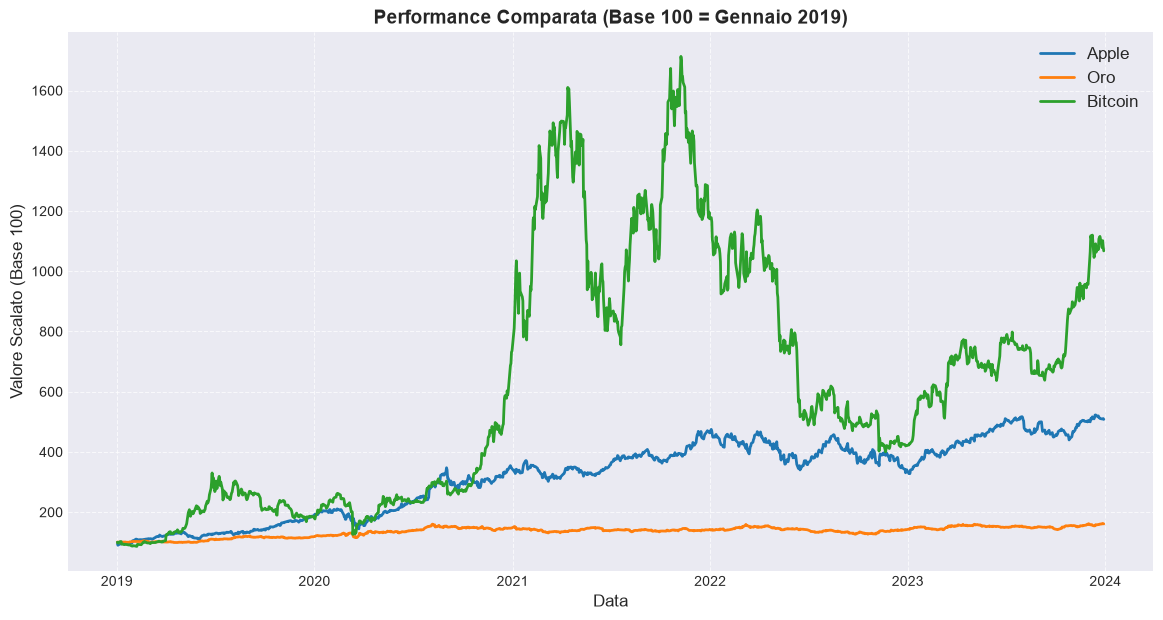

In [3]:
# Grafico Normalizzazione dei Prezzi (Base 100)
data_normalized = (data / data.iloc[0]) * 100

plt.figure(figsize=(14, 7))
for column in data_normalized.columns:
    plt.plot(data_normalized.index, data_normalized[column], label=column, linewidth=2)

plt.title('Performance Comparata (Base 100 = Gennaio 2019)', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Valore Scalato (Base 100)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [4]:
#Rendimenti logaritmici/percentuali e metriche di rischio
returns = data.pct_change().dropna()

# Calcolo di Rendimento Medio e Volatilità Annualizzati (252 giorni lavorativi)
annualized_returns = returns.mean() * 252
annualized_volatility = returns.std() * np.sqrt(252)

# Sharpe Ratio semplificato (assuming Risk-Free Rate = 0%)
sharpe_ratio = annualized_returns / annualized_volatility

# Creazione di una tabella riassuntiva
metrics = pd.DataFrame({'Rendimento Annualizzato (%)':(annualized_returns * 100).round(2),'Volatilità Annualizzata (%)': (annualized_volatility * 100).round(2),'Sharpe Ratio': sharpe_ratio.round(2)})

# Tabella formattata in HTML con gradiente cromatico
metrics.style\
    .background_gradient(cmap='Blues')\
    .format("{:.2f}")\
    .set_caption("Profilo Rischio/Rendimento (2019 - 2024)")

,Rendimento Annualizzato (%),Volatilità Annualizzata (%),Sharpe Ratio
Apple,37.80,32.23,1.17
Oro,10.78,15.69,0.69
Bitcoin,70.46,67.22,1.05


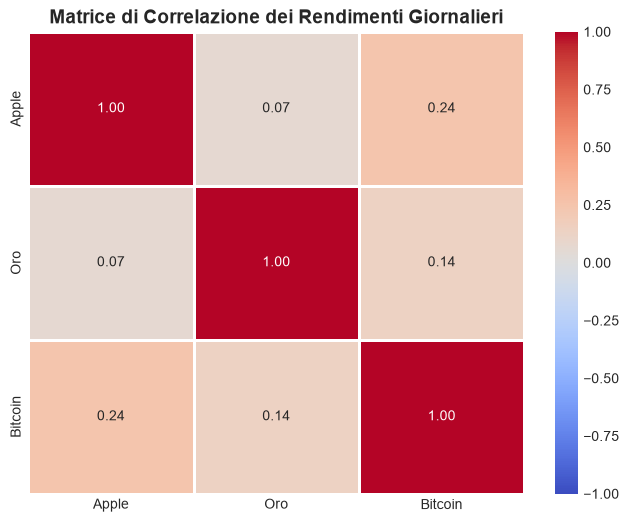

In [5]:
#Heatmap della Correlazione dei Rendimenti
plt.figure(figsize=(8, 6))
correlation_matrix = returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('Matrice di Correlazione dei Rendimenti Giornalieri', fontsize=14, fontweight='bold')
plt.show()

In [6]:
# Calcolo del Maximum Drawdown (Crollo Massimo)

# Calcolo i picchi massimi accumulati nel tempo
cumulative_returns = (1 + returns).cumprod()
peak = cumulative_returns.cummax()

# 2. Calcolo il Drawdown come percentuale di perdita dal picco
drawdown = (cumulative_returns - peak) / peak
max_drawdown = drawdown.min() * 100

# 3. Aggiungo il Max Drawdown alla nostra tabella delle metriche
metrics['Max Drawdown (%)'] = max_drawdown.abs().round(2)

# Tabella finale e completa 
metrics.style\
    .background_gradient(cmap='RdYlGn_r', subset=['Volatilità Annualizzata (%)', 'Max Drawdown (%)'])\
    .background_gradient(cmap='RdYlGn', subset=['Rendimento Annualizzato (%)', 'Sharpe Ratio'])\
    .format("{:.2f}")\
    .set_caption("Summary Finale Livello 1: Profilo Rischio/Rendimento Completo")

,Rendimento Annualizzato (%),Volatilità Annualizzata (%),Sharpe Ratio,Max Drawdown (%)
Apple,37.80,32.23,1.17,31.43
Oro,10.78,15.69,0.69,20.87
Bitcoin,70.46,67.22,1.05,76.63


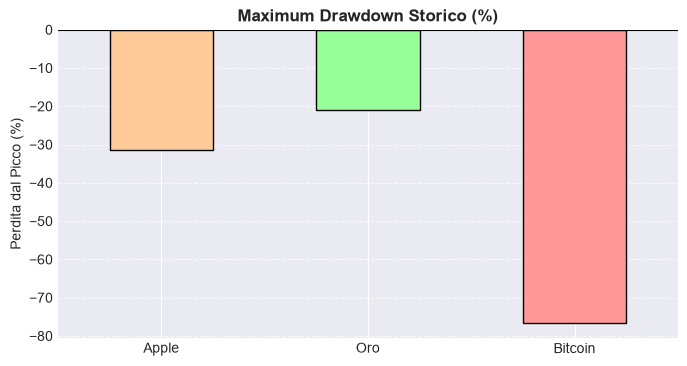

In [7]:
# Grafico a barre del Maximum Drawdown
plt.figure(figsize=(8, 4))
colors = ['#ff9999' if x < -50 else '#ffcc99' if x < -30 else '#99ff99' for x in max_drawdown]

max_drawdown.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Maximum Drawdown Storico (%)', fontsize=12, fontweight='bold')
plt.ylabel('Perdita dal Picco (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.show()

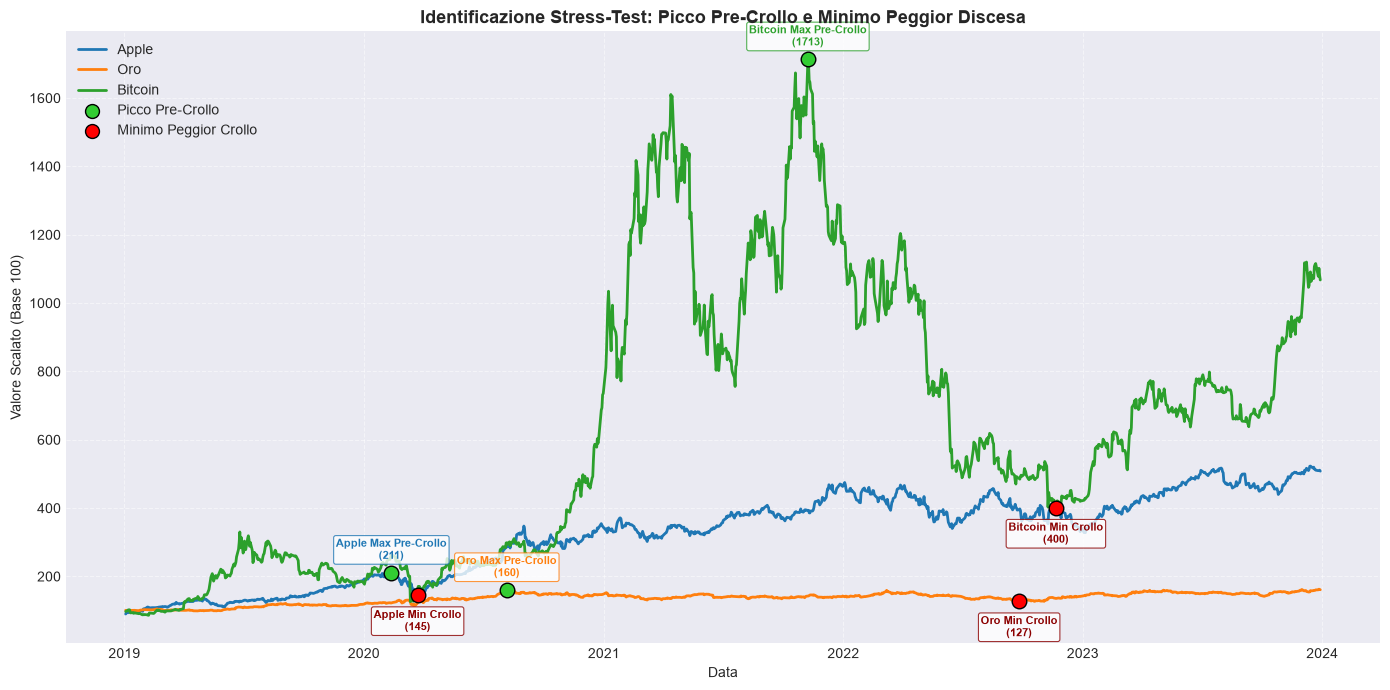

In [8]:
# 1. Ricalcolo di dei vettori cumulativi e drawdown
cum_ret = cumulative_returns if 'cumulative_returns' in locals() else (1 + returns).cumprod()
dd = drawdown if 'drawdown' in locals() else (cum_ret - cum_ret.cummax()) / cum_ret.cummax()

plt.figure(figsize=(14, 7))

for col in cum_ret.columns:
    curve = cum_ret[col] * 100
    
    # Linea dell'asset
    line, = plt.plot(curve.index, curve.values, label=col, linewidth=2)
    line_color = line.get_color()
    
    # A. MINIMO della discesa maggiore (Punto di Max Drawdown)
    data_min = dd[col].idxmin()
    val_min = curve.loc[data_min]
    
    # B. MASSIMO prima della discesa maggiore (Picco storico pre-crollo)
    data_peak = curve.loc[:data_min].idxmax()
    val_peak = curve.loc[data_peak]
    
    # Disegno dei marker
    plt.scatter(data_peak, val_peak, color='limegreen', s=110, edgecolor='black', zorder=5)
    plt.scatter(data_min, val_min, color='red', s=110, edgecolor='black', zorder=5)
    
    # Etichette di testo sul grafico
    plt.annotate(f"{col} Max Pre-Crollo\n({val_peak:.0f})", (data_peak, val_peak), 
                 textcoords="offset points", xytext=(0, 10), ha='center', 
                 fontsize=8, fontweight='bold', color=line_color,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=line_color, lw=0.8, alpha=0.8))
                 
    plt.annotate(f"{col} Min Crollo\n({val_min:.0f})", (data_min, val_min), 
                 textcoords="offset points", xytext=(0, -25), ha='center', 
                 fontsize=8, fontweight='bold', color='darkred',
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec='darkred', lw=0.8, alpha=0.8))

# Legenda per identificare i simboli
plt.scatter([], [], color='limegreen', s=100, edgecolor='black', label='Picco Pre-Crollo')
plt.scatter([], [], color='red', s=100, edgecolor='black', label='Minimo Peggior Crollo')

# Formattazione
plt.title('Identificazione Stress-Test: Picco Pre-Crollo e Minimo Peggior Discesa', fontsize=13, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Valore Scalato (Base 100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
#Calcolo Matriciale di un Portafoglio Equal-Weight

import numpy as np
import pandas as pd

# Definizione dei pesi del portafoglio Equal-Weight (1/3 ciascuno)
num_assets = len(returns.columns)
weights = np.array([1/num_assets] * num_assets)

# Rendimento medio giornaliero e Matrice di Covarianza giornaliera
mean_returns_daily = returns.mean()
cov_matrix_daily = returns.cov()

# Annualizzazione (252 giorni lavorativi)
mean_returns_annual = mean_returns_daily * 252
cov_matrix_annual = cov_matrix_daily * 252

# Rendimento Atteso di Portafoglio: E(Rp) = w^T * R
portfolio_return = np.dot(weights, mean_returns_annual)

# Rischio di Portafoglio (Varianza): sigma_p^2 = w^T * Sigma * w
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix_annual, weights))
portfolio_volatility = np.sqrt(portfolio_variance)

# Sharpe Ratio (Tasso Risk-Free assunta = 2.0%)
risk_free_rate = 0.02
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

# Visalizzazione dei risultati 
print("=" * 55)
print("  ANALISI PORTAFOGLIO EQUAL-WEIGHT (APPLE, ORO, BITCOIN)  ")
print("=" * 55)
print(f"Pesi Assegnati          : {np.round(weights * 100, 2)}%")
print(f"Rendimento Atteso Annuo : {portfolio_return * 100:.2f}%")
print(f"Varianza Annua (σ²)     : {portfolio_variance:.4f}")
print(f"Volatilità Annua (σ)    : {portfolio_volatility * 100:.2f}%")
print(f"Sharpe Ratio            : {sharpe_ratio:.2f}")
print("-" * 55)

  ANALISI PORTAFOGLIO EQUAL-WEIGHT (APPLE, ORO, BITCOIN)  
Pesi Assegnati          : [33.33 33.33 33.33]%
Rendimento Atteso Annuo : 39.68%
Varianza Annua (σ²)     : 0.0802
Volatilità Annua (σ)    : 28.32%
Sharpe Ratio            : 1.33
-------------------------------------------------------


In [10]:
# Calcolo metriche su base annua per i SINGOLI ASSET
returns_annual_single = mean_returns_annual
volatility_annual_single = np.sqrt(np.diag(cov_matrix_annual))
sharpe_single = (returns_annual_single - risk_free_rate) / volatility_annual_single

# Creazione del DataFrame riassuntivo per i singoli asset
df_assets = pd.DataFrame({'Rendimento Annuo (%)': returns_annual_single * 100,
    'Volatilità Annua (%)': volatility_annual_single * 100,'Sharpe Ratio': sharpe_single})

# Aggiunta della riga del PORTAFOGLIO EQUAL-WEIGHT
portfolio_row = pd.DataFrame({'Rendimento Annuo (%)': portfolio_return * 100,'Volatilità Annua (%)': portfolio_volatility * 100,'Sharpe Ratio': sharpe_ratio}, index=['Portafoglio Equal-Weight'])

# Uniamo i singoli asset e il portafoglio
df_comparison = pd.concat([df_assets, portfolio_row])

# Arrotondamento 
df_comparison = df_comparison.round(2)

# Visualizzazione
print("=" * 60)
print("     TABELLA COMPARATIVA PERFORMANCE E RISCHIO (SINGOLI VS PORTAFOGLIO)")
print("=" * 60)
print(df_comparison)
print("=" * 60)

     TABELLA COMPARATIVA PERFORMANCE E RISCHIO (SINGOLI VS PORTAFOGLIO)
                          Rendimento Annuo (%)  Volatilità Annua (%)  \
Apple                                    37.80                 32.23   
Oro                                      10.78                 15.69   
Bitcoin                                  70.46                 67.22   
Portafoglio Equal-Weight                 39.68                 28.32   

                          Sharpe Ratio  
Apple                             1.11  
Oro                               0.56  
Bitcoin                           1.02  
Portafoglio Equal-Weight          1.33  


In [11]:
# Visualizzazione diretta (Niente print!)
styled_table = df_comparison.style \
    .format({'Rendimento Annuo (%)': '{:.2%}','Volatilità Annua (%)': '{:.2%}','Sharpe Ratio': '{:.2f}'}) \
    .background_gradient(cmap='RdYlGn', subset=['Sharpe Ratio']) \
    .highlight_max(subset=['Rendimento Annuo (%)'], color='lightgreen') \
    .highlight_min(subset=['Volatilità Annua (%)'], color='lightgreen') \
    .set_caption("<b>Analisi Comparativa: Asset Singoli vs Portafoglio Equal-Weight</b>") \
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('text-align', 'center'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]}])
styled_table

,Rendimento Annuo (%),Volatilità Annua (%),Sharpe Ratio
Apple,3780.00%,3223.00%,1.11
Oro,1078.00%,1569.00%,0.56
Bitcoin,7046.00%,6722.00%,1.02
Portafoglio Equal-Weight,3968.00%,2832.00%,1.33


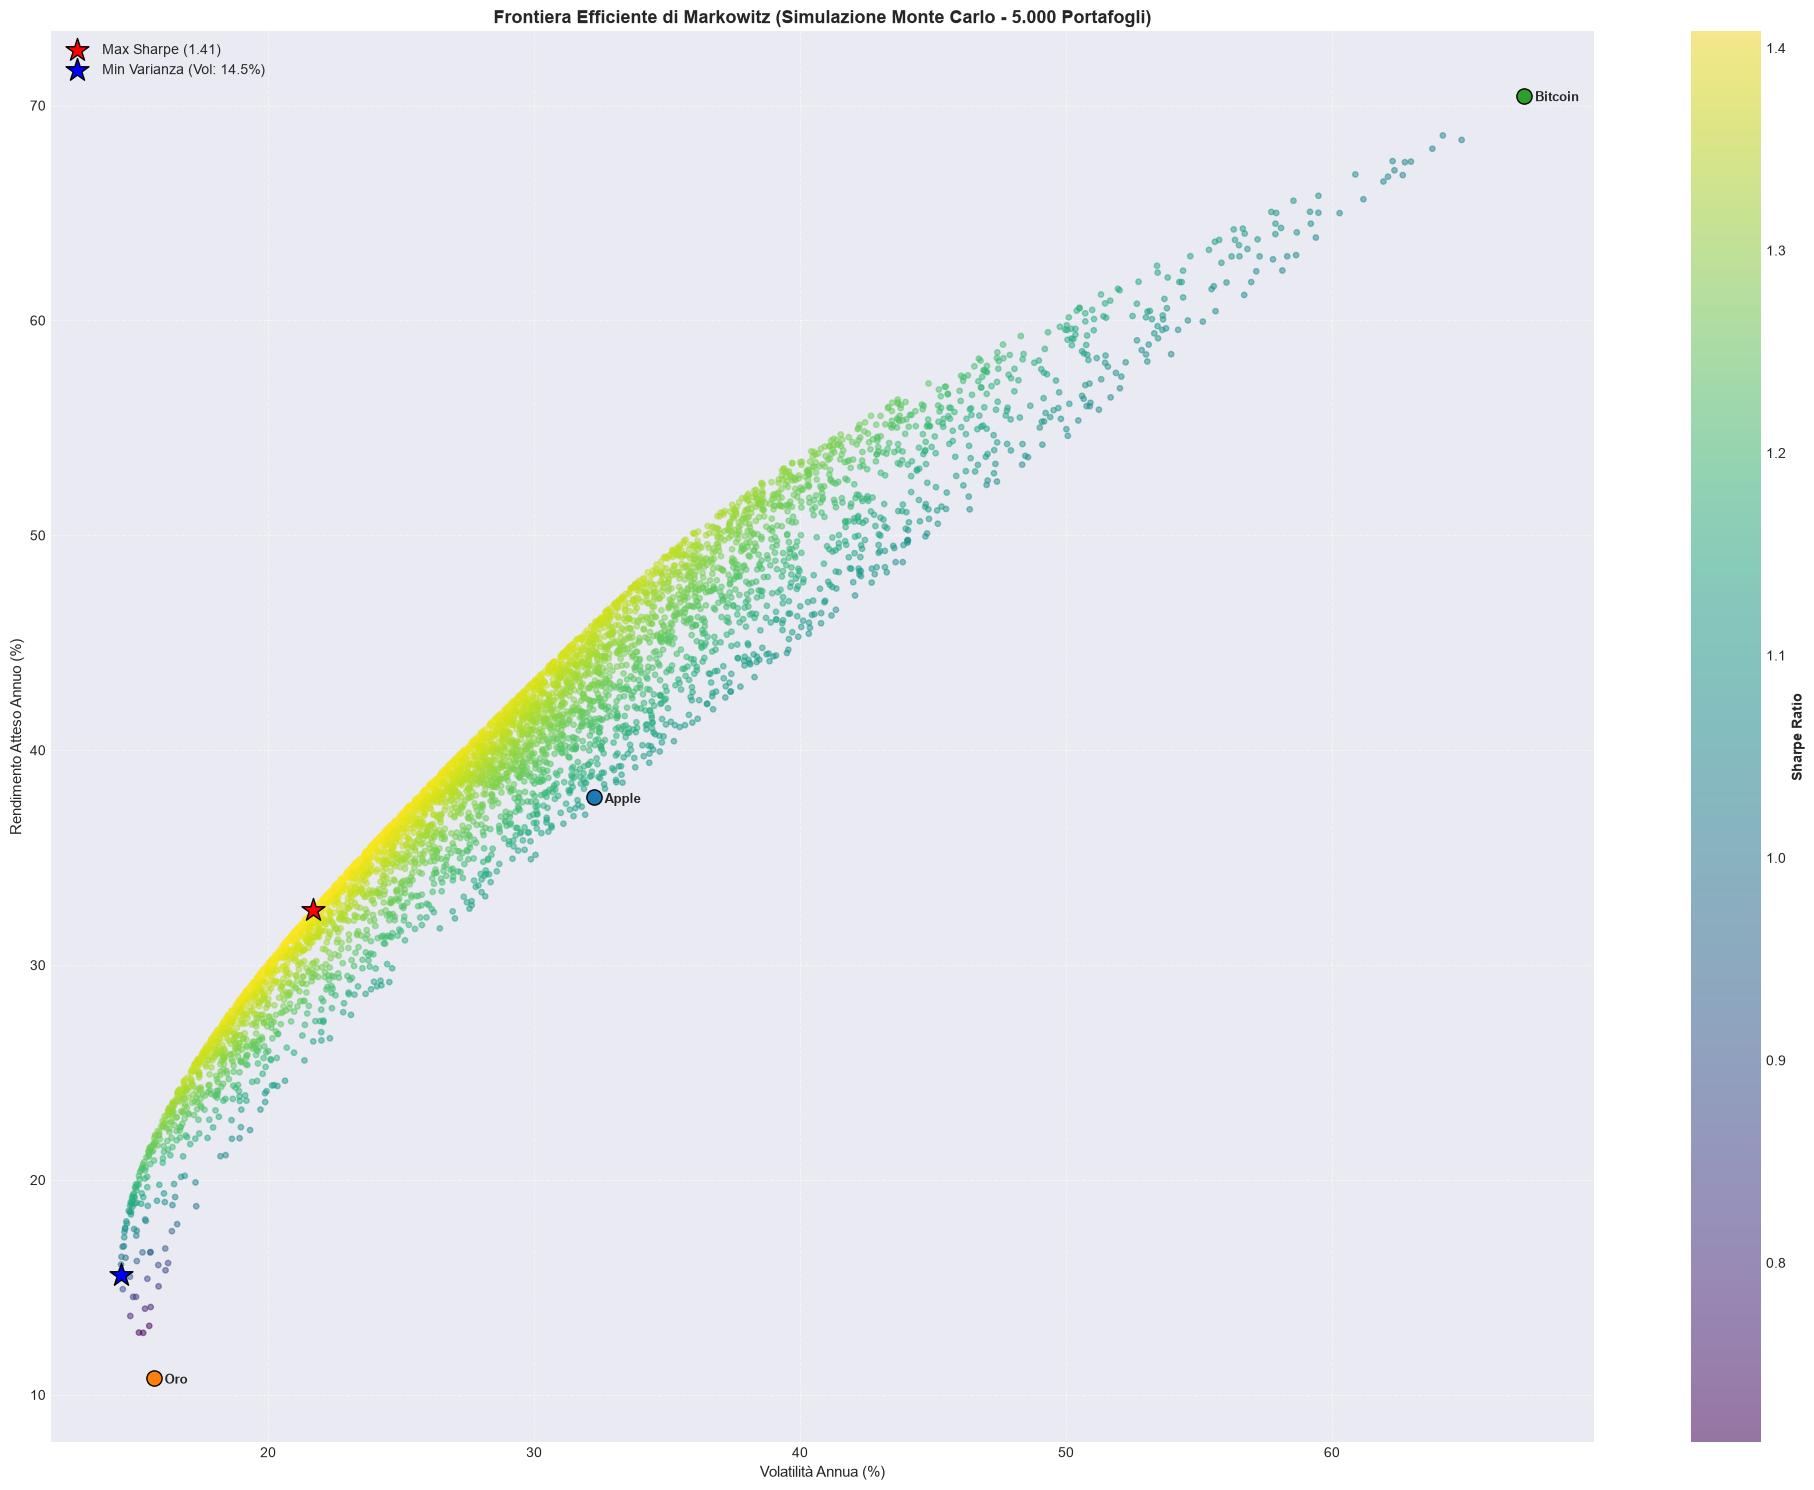

              PESI DEI PORTAFOGLI OTTIMI
PORTAFOGLIO MAX SHARPE RATIO:
  - Apple     :  43.19%
  - Oro       :  39.90%
  - Bitcoin   :  16.92%
  -> Rendimento Atteso: 32.55% | Volatilità: 21.69%

PORTAFOGLIO MINIMA VARIANZA:
  - Apple     :  16.54%
  - Oro       :  82.92%
  - Bitcoin   :   0.54%
  -> Rendimento Atteso: 15.57% | Volatilità: 14.47%


In [12]:
# Imposto il numero di simulazioni e fisso il seed per la riproducibilità
num_portfolios = 5000
np.random.seed(42)

# Vettori per salvare i risultati delle simulazioni
results = np.zeros((3, num_portfolios))
weights_record = []
num_assets = len(mean_returns_annual)

# Simulazione Monte Carlo
for i in range(num_portfolios):
    # Genero pesi casuali e li normalizziamo in modo che la somma sia 1 (100%)
    w = np.random.random(num_assets)
    w /= np.sum(w)
    weights_record.append(w)
    # Rendimento di portafoglio: w^T * R
    p_return = np.dot(w, mean_returns_annual)
    # Volatilità di portafoglio: sqrt(w^T * Sigma * w)
    p_volatility = np.sqrt(np.dot(w.T, np.dot(cov_matrix_annual, w)))
    # Salvataggio di Rendimento, Volatilità e Sharpe Ratio
    results[0, i] = p_return
    results[1, i] = p_volatility
    results[2, i] = (p_return - risk_free_rate) / p_volatility

# Converto la lista dei pesi in array NumPy per facilità di indicizzazione
weights_record = np.array(weights_record)

# Identificazione dei Portafogli Ottimi
max_sharpe_idx = np.argmax(results[2])
min_vol_idx = np.argmin(results[1])

# Estrazione dei dettagli
max_sharpe_port = results[:, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

min_vol_port = results[:, min_vol_idx]
min_vol_weights = weights_record[min_vol_idx]

# TRACCIAMENTO DEL GRAFICO (Frontiera Efficiente)
plt.figure(figsize=(20, 15))

# Cloud dei 5.000 portafogli colorati in base allo Sharpe Ratio
scatter = plt.scatter(results[1] * 100, results[0] * 100, c=results[2], 
                      cmap='viridis', marker='o', s=15, alpha=0.5)

# Colorbar per la scala dello Sharpe Ratio
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', fontsize=10, fontweight='bold')

# Evidenziamo i singoli asset puri
single_vols = np.sqrt(np.diag(cov_matrix_annual)) * 100
single_rets = np.array(mean_returns_annual) * 100
for i, col in enumerate(returns.columns):
    plt.scatter(single_vols[i], single_rets[i], s=120, edgecolor='black', zorder=4)
    plt.annotate(f"{col}", (single_vols[i], single_rets[i]), textcoords="offset points", 
                 xytext=(8, -4), fontweight='bold', fontsize=9)

# Marker per i Portafogli Ottimi
plt.scatter(max_sharpe_port[1] * 100, max_sharpe_port[0] * 100, color='red', 
            marker='*', s=300, edgecolor='black', label=f'Max Sharpe ({max_sharpe_port[2]:.2f})', zorder=5)
plt.scatter(min_vol_port[1] * 100, min_vol_port[0] * 100, color='blue', 
            marker='*', s=300, edgecolor='black', label=f'Min Varianza (Vol: {min_vol_port[1]*100:.1f}%)', zorder=5)

plt.title('Frontiera Efficiente di Markowitz (Simulazione Monte Carlo - 5.000 Portafogli)', fontsize=13, fontweight='bold')
plt.xlabel('Volatilità Annua (%)', fontsize=11)
plt.ylabel('Rendimento Atteso Annuo (%)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# Stampa dei pesi dei portafogli ottimi
print("=" * 60)
print("              PESI DEI PORTAFOGLI OTTIMI")
print("=" * 60)
print("PORTAFOGLIO MAX SHARPE RATIO:")
for asset, weight in zip(returns.columns, max_sharpe_weights):
    print(f"  - {asset:10s}: {weight * 100:6.2f}%")
print(f"  -> Rendimento Atteso: {max_sharpe_port[0]*100:.2f}% | Volatilità: {max_sharpe_port[1]*100:.2f}%")

print("\nPORTAFOGLIO MINIMA VARIANZA:")
for asset, weight in zip(returns.columns, min_vol_weights):
    print(f"  - {asset:10s}: {weight * 100:6.2f}%")
print(f"  -> Rendimento Atteso: {min_vol_port[0]*100:.2f}% | Volatilità: {min_vol_port[1]*100:.2f}%")
print("=" * 60)

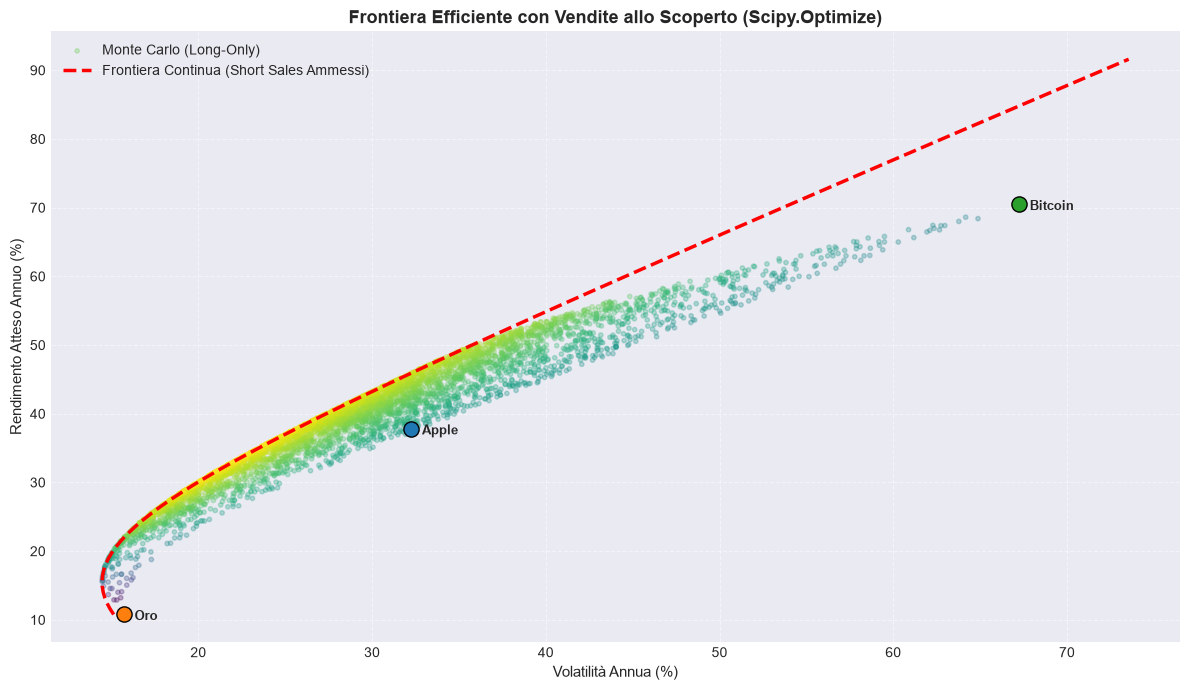

In [13]:
from scipy.optimize import minimize

# Definizione della funzione obiettivo (Varianza di portafoglio)
def portfolio_variance(weights, cov_matrix):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

num_assets = len(mean_returns_annual)

# Generazione della griglia dei Rendimenti Target (estendendo oltre Bitcoin)
# Andiamo da un rendimento minimo fino a un valore superiore al max rendimento singolo
min_ret = mean_returns_annual.min()
max_ret = mean_returns_annual.max() * 1.3  # Estendo oltre BTC per mostrare lo Short Selling
target_returns = np.linspace(min_ret, max_ret, 100)

efficient_vols = []
efficient_weights = []

# Risoluzione dell'ottimizzazione per ogni rendimento target
for target in target_returns:
    # Constraints: 
    # 1) Somma dei pesi = 1 (sum(w) - 1 = 0)
    # 2) Rendimento di portafoglio = target (w^T * R - target = 0)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},{'type': 'eq', 'fun': lambda w: np.dot(w, mean_returns_annual) - target})
    
    # Nessun vincolo sulle bounds -> Pesi liberi in (-inf, +inf) = Short Sales ammessi!
    # Pesi iniziali trascurabili (Guess iniziale Equal-Weight)
    init_guess = num_assets * [1.0 / num_assets]
    
    # Esecuzione dell'ottimizzatore SLSQP (Sequential Least Squares Programming)
    opt_result = minimize(portfolio_variance, init_guess, args=(cov_matrix_annual,),method='SLSQP',constraints=constraints)
    
    # Salviamo la volatilità (radice della varianza minima trovata) e i pesi
    efficient_vols.append(np.sqrt(opt_result.fun))
    efficient_weights.append(opt_result.x)

efficient_vols = np.array(efficient_vols) * 100
target_returns_pct = target_returns * 100

# Tracciamento del Grafico: Frontiera Continua vs Simulazione
plt.figure(figsize=(12, 7))

# Ripropongo lo sfondo della simulazione Monte Carlo Long-Only per confronto
scatter = plt.scatter(results[1] * 100, results[0] * 100, c=results[2], 
                      cmap='viridis', marker='o', s=10, alpha=0.3, label='Monte Carlo (Long-Only)')

# Traccio la curva continua con Short Sales
plt.plot(efficient_vols, target_returns_pct, color='red', linestyle='--', 
         linewidth=2.5, label='Frontiera Continua (Short Sales Ammessi)', zorder=5)

# Singoli Asset
single_vols = np.sqrt(np.diag(cov_matrix_annual)) * 100
single_rets = np.array(mean_returns_annual) * 100
for i, col in enumerate(returns.columns):
    plt.scatter(single_vols[i], single_rets[i], s=120, edgecolor='black', zorder=6)
    plt.annotate(f"{col}", (single_vols[i], single_rets[i]), textcoords="offset points", 
                 xytext=(8, -4), fontweight='bold', fontsize=9)

plt.title('Frontiera Efficiente con Vendite allo Scoperto (Scipy.Optimize)', fontsize=13, fontweight='bold')
plt.xlabel('Volatilità Annua (%)', fontsize=11)
plt.ylabel('Rendimento Atteso Annuo (%)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
# Definisco il rendimento target desiderato (es. 60%)
target_desiderato = 0.60

# Calcolo l'indice del rendimento target più vicino a quello desiderato nella nostra griglia
idx_target = np.abs(target_returns - target_desiderato).argmin()

# Estraiamo i pesi ottimi corrispondenti e la volatilità
pesi_ottimi = efficient_weights[idx_target]
volatilita_ottima = efficient_vols[idx_target]
rendimento_effettivo = target_returns[idx_target] * 100

# Stampa formattata dei risultati con evidenza delle posizioni Short
print(f"=== PORTAFOGLIO OTTIMO PER RENDIMENTO TARGET ~{target_desiderato*100:.0f}% ===")
print(f"Rendimento Atteso: {rendimento_effettivo:.2f}% | Volatilità Annua: {volatilita_ottima:.2f}%\n")
print("Allocazione dei Pesi:")

for asset, weight in zip(returns.columns, pesi_ottimi):
    percentuale = weight * 100
    if percentuale < 0:
        tipo_posizione = "SHORT (Vendita allo scoperto)"
    else:
        tipo_posizione = "LONG (Acquisto)"
        
    print(f"  - {asset:10s}: {percentuale:7.2f}%  -->  {tipo_posizione}")

print("-" * 55)
print(f"  SOMMA TOTALE PESI: {np.sum(pesi_ottimi)*100:.2f}% (Vincolo di bilancio rispettato)")

=== PORTAFOGLIO OTTIMO PER RENDIMENTO TARGET ~60% ===
Rendimento Atteso: 59.76% | Volatilità Annua: 44.38%

Allocazione dei Pesi:
  - Apple     :   83.98%  -->  LONG (Acquisto)
  - Oro       :  -28.03%  -->  SHORT (Vendita allo scoperto)
  - Bitcoin   :   44.05%  -->  LONG (Acquisto)
-------------------------------------------------------
  SOMMA TOTALE PESI: 100.00% (Vincolo di bilancio rispettato)
